In [1]:
# data set up
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# data load
df = pd.read_csv('/content/drive/MyDrive/Telco-Customer-Churn_suraj singh g40aiml.csv')
# data clean
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"data clean rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(df.head())



ModuleNotFoundError: No module named 'pandas'


EDA Churn Distribution & Boxplots


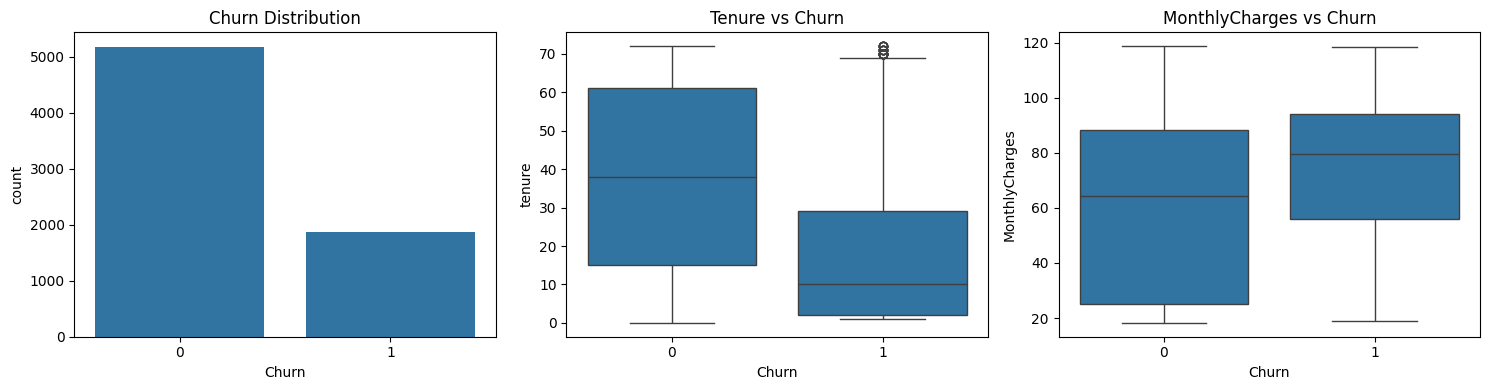


Split: Train=5634, Test=1409


In [ ]:
%matplotlib inline
# 1. Numeric Features
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
# 2. Categorical Features
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                         'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                         'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                         'Contract', 'PaperlessBilling', 'PaymentMethod']
print("\nEDA Churn Distribution & Boxplots")
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')

plt.subplot(1,3,2)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')

plt.subplot(1,3,3)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('MonthlyCharges vs Churn')

plt.tight_layout()
plt.show()

# Train-Test
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nSplit: Train={X_train.shape[0]}, Test={X_test.shape[0]}")

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Columns are seprate, using the actual column names
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                         'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                         'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                         'Contract', 'PaperlessBilling', 'PaymentMethod']

# Numeric pipeline missing value
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: Missing values fill with inner mode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# both are combined tranform
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])
print(X_train.shape[0], "Test size:", X_test.shape[0])

5634 Test size: 1409


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# constructing the pipeline
model = RandomForestClassifier(
    n_estimators = 100,
    random_state=42,
    class_weight='balanced'
)
# master pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', model)
])

# train
pipeline.fit(X_train, y_train)
print("model tarin")
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1] # Changed X_train to X_test
print("\n " + " *50")
print("base model score")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")


model tarin

  *50
base model score
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.821


In [ ]:
from sklearn.model_selection import GridSearchCV

# HYPER_METER
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    # Progress
    verbose=1
)

grid.fit(X_train, y_train)

print(f"\n Best Parameter: {grid.best_params_}")
print(f"Best Cv Score: {grid.best_score_:.3f}")

best_pipeline = grid.best_estimator_

# Tuned model ka evaluation
y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

print("TUNED MODEL FINAL SCORE")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best):.3f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print( grid.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

 Best Parameter: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best Cv Score: 0.845
TUNED MODEL FINAL SCORE
              precision    recall  f1-score   support

    No Churn       0.89      0.78      0.83      1035
       Churn       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

ROC-AUC: 0.839
Confusion Matrix:
[[807 228]
 [104 270]]
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


In [ ]:
import joblib

# model save
model_path = '/content/drive/MyDrive/churn_pipeline_final.pkl'
joblib.dump(best_pipeline, model_path)
print ("model save")

model save
